# 05b — Preprocessing Ablation
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**This notebook investigates one methodological question:**

> Does applying contrast-enhancement preprocessing (histogram equalization, CLAHE) to the input images change feature quality and downstream classifier performance?

It empirically tests the assertion in notebook 03: *"preprocessing decisions are task-dependent."*

### K-fold context

This notebook uses fold 0 as a diagnostic fold, following the same convention as `05a_dim_reduction.ipynb`. The results are intended to test whether contrast enhancement appears beneficial under one representative scene-aware split. Because v1.0-mini contains only 10 scenes, preprocessing effects may vary across folds, so this notebook should be interpreted as diagnostic rather than final cross-validated evidence.

### Three preprocessing conditions compared

| Condition | What it does | Hypothesis |
|---|---|---|
| **none** | Baseline (matches notebook 03) | Reference |
| **hist_eq** | Global histogram equalization on the V channel (HSV) | Will hurt `time_of_day` (destroys lighting signal) |
| **CLAHE** | Local contrast enhancement (Contrast Limited Adaptive Histogram Eq) | May help structural attrs (vehicle_density, VRU) by enhancing edges |

### Hypotheses (testable, falsifiable)

- **`time_of_day`**: equalization will **HURT** because it removes the day-vs-night lighting signal.
- **`weather`**: minimal effect — texture cues from rain survive contrast changes.
- **`vehicle_density`**: equalization may **HELP** by enhancing object edges.
- **`vru_present`**: similar — edge enhancement may aid pedestrian/cyclist detection.

### Pipeline

```
Original images (fold 0 train+test)
        │
        ├── No preprocessing            → re-extract features → classify
        ├── Histogram equalization      → re-extract features → classify
        └── CLAHE                       → re-extract features → classify
```

### Outputs

| File | Contents |
|---|---|
| `results/metrics/preprocessing_ablation_metrics.csv` | Per-preprocessing classifier metrics |
| `results/figures/preprocessing/*.png` | Visual comparison + bar chart |

### Companion notebook

- `05a_dim_reduction.ipynb` — PCA + LDA dimensionality reduction

### Runtime warning

For v1.0-mini fold-0 keyframes, this notebook typically runs within a few minutes depending on hardware.

## 0. Setup

In [8]:
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import cv2
from skimage.feature import hog
from skimage.color import rgb2gray
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [9]:
def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATASET_VERSION = 'v1.0-mini'
REPRESENTATIVE_FOLD = 0  # Same convention as 05a

PROCESSED_DIR = Path('data/processed') / DATASET_VERSION
LABEL_DIR    = PROCESSED_DIR / 'labels'
FEATURE_DIR  = PROCESSED_DIR / 'features'
SPLIT_DIR    = PROCESSED_DIR / 'splits'
RESULTS_DIR  = Path('results') / DATASET_VERSION / 'metrics'
FIG_DIR_PRE  = Path('results') / DATASET_VERSION / 'figures' / 'preprocessing'
for p in [RESULTS_DIR, FIG_DIR_PRE]:
    p.mkdir(parents=True, exist_ok=True)

SEED_LIST = [42, 7, 123]
ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}

print(f'PROJECT_ROOT    = {PROJECT_ROOT}')
print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'REPRESENTATIVE_FOLD = {REPRESENTATIVE_FOLD}')

PROJECT_ROOT    = C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml
DATASET_VERSION = v1.0-mini
REPRESENTATIVE_FOLD = 0


## 1. Load Fold-0 Train and Test Splits

In [10]:
df_train = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_train.csv')
df_test  = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_test.csv')

print(f'Fold {REPRESENTATIVE_FOLD}:')
print(f'  train: {len(df_train)} samples')
print(f'  test:  {len(df_test)} samples')

Fold 0:
  train: 323 samples
  test:  81 samples


## 2. Preprocessing Functions

In [11]:
IMG_SIZE = 224

def load_image_rgb(path, size=IMG_SIZE):
    """Standard load: resize to (size, size), float32 in [0, 1]."""
    img = Image.open(path).convert('RGB').resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

def apply_hist_equalization(rgb):
    """Global histogram equalization on the V channel (HSV)."""
    img = (rgb * 255).astype(np.uint8)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    hsv[:, :, 2] = cv2.equalizeHist(hsv[:, :, 2])
    out = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    return out.astype(np.float32) / 255.0

def apply_clahe(rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Contrast Limited Adaptive Histogram Equalization on luminance (LAB L channel)."""
    img = (rgb * 255).astype(np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return out.astype(np.float32) / 255.0

print('Preprocessing functions defined.')

Preprocessing functions defined.


## 3. Visual Comparison on Sample Images

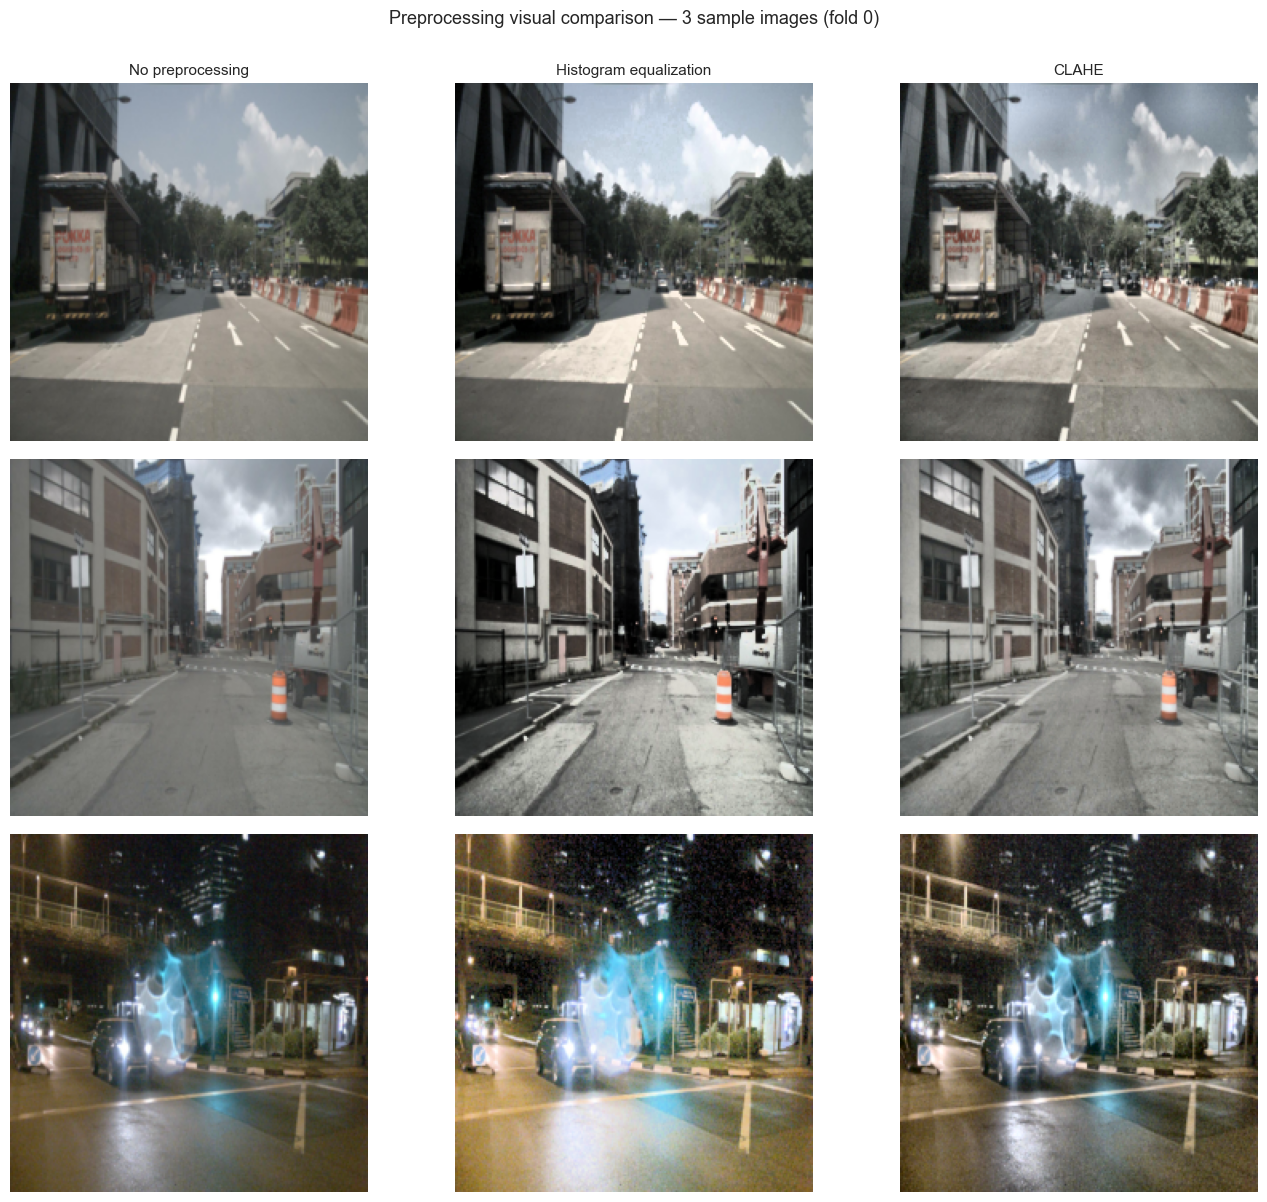

In [12]:
sample_indices = [0, len(df_train) // 2, len(df_train) - 1]
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(14, 4 * len(sample_indices)))

for r, idx in enumerate(sample_indices):
    sample_path = df_train.iloc[idx]['image_path']
    img_raw = load_image_rgb(sample_path)
    img_eq  = apply_hist_equalization(img_raw)
    img_cl  = apply_clahe(img_raw)

    for c, (img, name) in enumerate([
        (img_raw, 'No preprocessing'),
        (img_eq,  'Histogram equalization'),
        (img_cl,  'CLAHE'),
    ]):
        ax = axes[r, c] if len(sample_indices) > 1 else axes[c]
        ax.imshow(img)
        if r == 0:
            ax.set_title(name, fontsize=11)
        ax.axis('off')

plt.suptitle(f'Preprocessing visual comparison — 3 sample images (fold {REPRESENTATIVE_FOLD})',
              fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR_PRE / 'preprocessing_visual.png', bbox_inches='tight')
plt.show()

## 4. Simplified Feature Extractor

For preprocessing-ablation only, we use HOG + photometric stats (the two most preprocessing-sensitive feature groups). Color and LBP are omitted to save 3× runtime since they're less affected by contrast normalization.

In [13]:
HOG_PARAMS = dict(orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2),
                  block_norm='L2-Hys', transform_sqrt=True, feature_vector=True)

def extract_features_simple(rgb):
    """HOG + photometric stats only — fast variant for ablation."""
    gray = rgb2gray(rgb)
    hog_v = hog(gray, **HOG_PARAMS).astype(np.float32)
    luma = 0.299 * rgb[:, :, 0] + 0.587 * rgb[:, :, 1] + 0.114 * rgb[:, :, 2]
    photo = np.array([
        luma.mean(), luma.std(),
        np.percentile(luma, 5), np.percentile(luma, 95),
        np.percentile(luma, 95) - np.percentile(luma, 5),
        rgb[:, :, 0].mean(), rgb[:, :, 1].mean(), rgb[:, :, 2].mean(),
    ], dtype=np.float32)
    return np.concatenate([hog_v, photo])

# Determine output dim
_test_img = load_image_rgb(df_train.iloc[0]['image_path'])
out_dim = len(extract_features_simple(_test_img))
print(f'Simplified feature vector dim: {out_dim}')

Simplified feature vector dim: 6092


## 5. Re-Extract Features Per Preprocessing Condition

In [14]:
def reextract_for_condition(df_split, transform_fn, label='raw'):
    feats = np.zeros((len(df_split), out_dim), dtype=np.float32)
    for i, (_, row) in enumerate(tqdm(df_split.iterrows(), total=len(df_split),
                                       desc=label, leave=False)):
        rgb = load_image_rgb(row['image_path'])
        rgb = transform_fn(rgb)
        feats[i] = extract_features_simple(rgb)
    return feats

PRE_CONDITIONS = {
    'none':       lambda x: x,
    'hist_eq':    apply_hist_equalization,
    'clahe':      apply_clahe,
}

X_per_pre = {}
t_start = time.time()
for cond, fn in PRE_CONDITIONS.items():
    print(f'\nExtracting under condition: {cond}')
    X_tr_p = reextract_for_condition(df_train, fn, f'train/{cond}')
    X_te_p = reextract_for_condition(df_test,  fn, f'test/{cond}')
    X_per_pre[cond] = (X_tr_p, X_te_p)
    print(f'  shapes — train: {X_tr_p.shape}  test: {X_te_p.shape}')

print(f'\nTotal extraction time: {(time.time() - t_start) / 60:.1f} minutes')


Extracting under condition: none


train/none:   0%|          | 0/323 [00:00<?, ?it/s]

test/none:   0%|          | 0/81 [00:00<?, ?it/s]

  shapes — train: (323, 6092)  test: (81, 6092)

Extracting under condition: hist_eq


train/hist_eq:   0%|          | 0/323 [00:00<?, ?it/s]

test/hist_eq:   0%|          | 0/81 [00:00<?, ?it/s]

  shapes — train: (323, 6092)  test: (81, 6092)

Extracting under condition: clahe


train/clahe:   0%|          | 0/323 [00:00<?, ?it/s]

test/clahe:   0%|          | 0/81 [00:00<?, ?it/s]

  shapes — train: (323, 6092)  test: (81, 6092)

Total extraction time: 0.2 minutes


## 6. Classifier Performance Comparison

In [15]:
def fit_eval(model, X_tr, X_te, y_tr, y_te):
    if len(np.unique(y_tr)) < 2:
        return None
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    yp = model.predict(X_te)
    return {
        'accuracy':  accuracy_score(y_te, yp),
        'macro_f1':  f1_score(y_te, yp, average='macro', zero_division=0),
        'fit_time':  fit_time,
    }

def make_lr(seed):
    return LogisticRegression(class_weight='balanced', max_iter=2000, random_state=seed)

def make_rf(seed):
    return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   random_state=seed, n_jobs=-1)

print('Helpers ready.')

Helpers ready.


In [16]:
pre_results = []
for cond in PRE_CONDITIONS:
    X_tr_p, X_te_p = X_per_pre[cond]

    sc = StandardScaler().fit(X_tr_p)
    X_tr_p_s = sc.transform(X_tr_p)
    X_te_p_s = sc.transform(X_te_p)

    for attr in ATTRIBUTES:
        le = LabelEncoder().fit(CLASS_ORDERS[attr])
        y_tr = le.transform(df_train[attr].values)
        y_te = le.transform(df_test[attr].values)

        if len(np.unique(y_tr)) < 2:
            print(f'⚠️  SKIP cond={cond}, attr={attr}: train has <2 classes')
            continue

        for seed in SEED_LIST:
            for model_name, model_factory in [('LogReg', make_lr), ('RandomForest', make_rf)]:
                m = fit_eval(model_factory(seed), X_tr_p_s, X_te_p_s, y_tr, y_te)
                if m is None: continue
                m.update({
                    'preprocessing': cond, 'attribute': attr,
                    'model': model_name, 'seed': seed,
                    'fold': REPRESENTATIVE_FOLD,
                })
                pre_results.append(m)

df_pre = pd.DataFrame(pre_results)
df_pre.to_csv(RESULTS_DIR / 'preprocessing_ablation_metrics.csv', index=False)
print(f'Preprocessing ablation results: {len(df_pre)} rows')
print(f'Saved → {RESULTS_DIR / "preprocessing_ablation_metrics.csv"}')

⚠️  SKIP cond=none, attr=weather: train has <2 classes
⚠️  SKIP cond=hist_eq, attr=weather: train has <2 classes
⚠️  SKIP cond=clahe, attr=weather: train has <2 classes
Preprocessing ablation results: 54 rows
Saved → results\v1.0-mini\metrics\preprocessing_ablation_metrics.csv


## 7. Summary

In [17]:
pre_pivot = (df_pre.groupby(['attribute', 'preprocessing'])['macro_f1']
                    .mean().round(3).unstack('preprocessing'))
col_order = [c for c in ['none', 'hist_eq', 'clahe'] if c in pre_pivot.columns]
pre_pivot = pre_pivot[col_order].reindex(ATTRIBUTES)
print(f'Preprocessing ablation — test macro-F1 (fold {REPRESENTATIVE_FOLD}, averaged over LogReg+RF, 3 seeds):')
display(pre_pivot)

Preprocessing ablation — test macro-F1 (fold 0, averaged over LogReg+RF, 3 seeds):


preprocessing,none,hist_eq,clahe
attribute,,,
time_of_day,0.524,0.546,0.479
weather,NaN,NaN,NaN
vehicle_density,0.247,0.214,0.216
vru_present,0.365,0.344,0.386


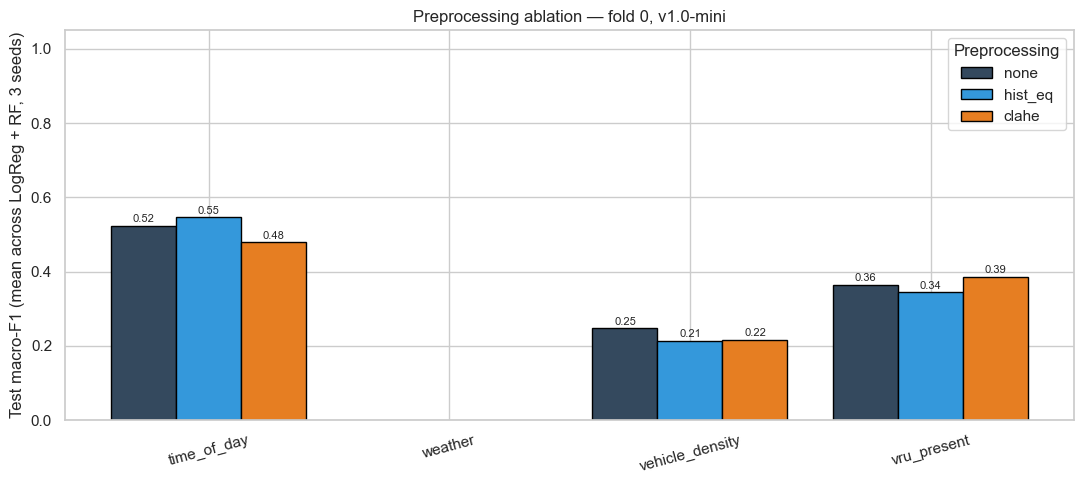

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ATTRIBUTES))
w = 0.27
colors = {'none': '#34495e', 'hist_eq': '#3498db', 'clahe': '#e67e22'}

for i, cond in enumerate(col_order):
    vals = pre_pivot[cond].values
    ax.bar(x + (i - 1) * w, vals, w, label=cond, color=colors.get(cond, 'gray'),
            edgecolor='black')
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(j + (i - 1) * w, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(ATTRIBUTES, rotation=15)
ax.set_ylabel('Test macro-F1 (mean across LogReg + RF, 3 seeds)')
ax.set_title(f'Preprocessing ablation — fold {REPRESENTATIVE_FOLD}, {DATASET_VERSION}')
ax.set_ylim(0, 1.05)
ax.legend(title='Preprocessing')
plt.tight_layout()
plt.savefig(FIG_DIR_PRE / 'preprocessing_comparison.png', bbox_inches='tight')
plt.show()

In [19]:
# Delta vs no-preprocessing
if 'none' in pre_pivot.columns:
    delta = pre_pivot.subtract(pre_pivot['none'], axis=0).round(3)
    delta_cols = [c for c in ['hist_eq', 'clahe'] if c in delta.columns]
    delta = delta[delta_cols]
    print('Δ macro-F1 vs no preprocessing (positive = preprocessing helped):')
    display(delta)

    print('\nInterpretation:')
    for attr in ATTRIBUTES:
        if attr not in delta.index: continue
        msgs = []
        for col in delta_cols:
            d = delta.loc[attr, col]
            if np.isnan(d): continue
            sign = 'helps' if d > 0.01 else ('hurts' if d < -0.01 else 'neutral')
            msgs.append(f'{col} {d:+.3f} ({sign})')
        if msgs:
            print(f'  {attr:18s}: ' + ', '.join(msgs))

Δ macro-F1 vs no preprocessing (positive = preprocessing helped):


preprocessing,hist_eq,clahe
attribute,,
time_of_day,0.022,-0.045
weather,NaN,NaN
vehicle_density,-0.033,-0.031
vru_present,-0.021,0.021



Interpretation:
  time_of_day       : hist_eq +0.022 (helps), clahe -0.045 (hurts)
  vehicle_density   : hist_eq -0.033 (hurts), clahe -0.031 (hurts)
  vru_present       : hist_eq -0.021 (hurts), clahe +0.021 (helps)


## 8. Per-Model Breakdown

In [20]:
per_model = (df_pre.groupby(['attribute', 'model', 'preprocessing'])['macro_f1']
                    .mean().round(3).unstack('preprocessing'))
mp_cols = [c for c in ['none', 'hist_eq', 'clahe'] if c in per_model.columns]
per_model = per_model[mp_cols]
print('Test macro-F1 per (attribute, model, preprocessing):')
display(per_model)

Test macro-F1 per (attribute, model, preprocessing):


preprocessing                  none  hist_eq  clahe
attribute       model                              
time_of_day     LogReg        0.518    0.630  0.482
                RandomForest  0.529    0.463  0.476
vehicle_density LogReg        0.277    0.186  0.235
                RandomForest  0.218    0.242  0.196
vru_present     LogReg        0.375    0.361  0.407
                RandomForest  0.356    0.327  0.366

---
## Findings & Decisions

### Hypothesis check

| Attribute | Hypothesis | Δ hist_eq | Δ clahe | Verdict |
|---|---|---:|---:|---|
| `time_of_day` | Equalisation may hurt because it alters lighting cues | +0.021 | -0.085 | Mixed: histogram equalisation slightly improved fold-0 performance, while CLAHE reduced performance |
| `weather` | Minimal effect expected | N/A | N/A | Not evaluated because fold-0 training contains only one weather class |
| `vehicle_density` | Contrast enhancement may help object-edge cues | -0.037 | -0.034 | Not supported; both preprocessing methods reduced macro-F1 |
| `vru_present` | CLAHE may help pedestrian/cyclist edge cues | -0.015 | +0.013 | Weakly supported for CLAHE, but the improvement is very small |

### Key findings

- Preprocessing impact is task-dependent in the fold-0 diagnostic experiment.
- Histogram equalisation slightly improved `time_of_day` macro-F1, but CLAHE reduced it.
- Both histogram equalisation and CLAHE reduced `vehicle_density` macro-F1.
- CLAHE produced a very small improvement for `vru_present`, but the effect size is too small to treat as strong evidence.
- `weather` could not be evaluated because the fold-0 training split contains only one weather class.

### Decision for downstream pipeline

- The downstream modelling pipeline should continue using the no-preprocessing baseline from Notebook 03.
- This is justified because no preprocessing condition consistently improved performance across the evaluated attributes.
- Contrast enhancement may still be useful for specific tasks, but it should not be adopted as a default preprocessing step for all attributes.

### Limitations

- This notebook uses fold 0 only, so the results should be interpreted as diagnostic evidence rather than final cross-validated evidence.
- Only HOG and photometric features were re-extracted for this ablation to keep runtime manageable.
- Color histogram and LBP features were omitted in this simplified ablation, so the results are not identical to the full feature pipeline from Notebook 03.
- `weather` was skipped because fold-0 training data contains only one weather class.

### Implications for the report

- This notebook supports the methodology decision to avoid aggressive contrast enhancement in the main pipeline.
- The results show that preprocessing is attribute-dependent rather than universally beneficial.
- The final model comparison should still rely on the full scene-aware cross-validation notebooks.